## Setup môi trường và Data 

In [35]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv('medical_insurance.csv')

In [37]:
print("=== TỔNG QUAN dfSET ===")
print(f"Kích thước dfset: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"\nCác columns: {list(df.columns)}")

# Hiển thị 5 dòng đầu
print("\n=== 5 DÒNG ĐẦU TIÊN ===")
df.head()

=== TỔNG QUAN dfSET ===
Kích thước dfset: 2772 dòng × 7 cột

Các columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

=== 5 DÒNG ĐẦU TIÊN ===


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print("Tổng số ô thiếu:", df.isnull().sum().sum())

Tổng số ô thiếu: 0


## 2. Trực quan hóa dữ liệu

### 2.1  Phân phối chi phí (charges)

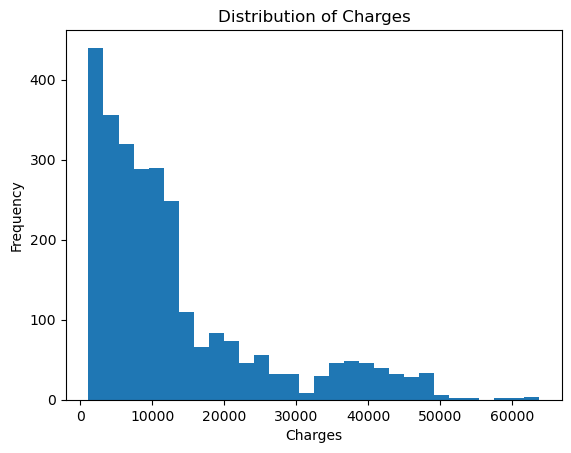

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

#### lệch phải rất mạnh → người hút thuốc thường kéo chi phí lên cao

### 2.2 Age vs Charges

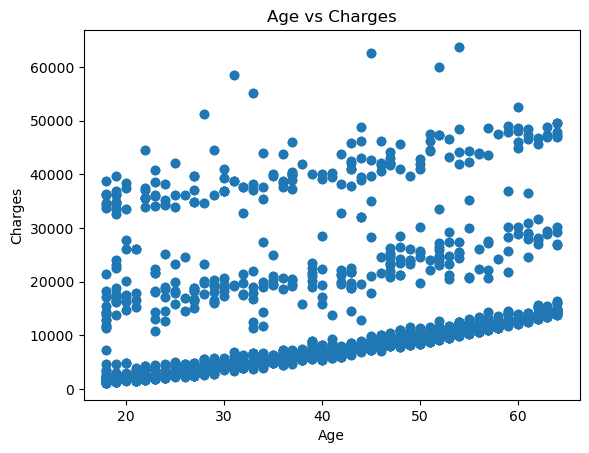

In [39]:
plt.figure()
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

### 2.3. BMI vs Charges

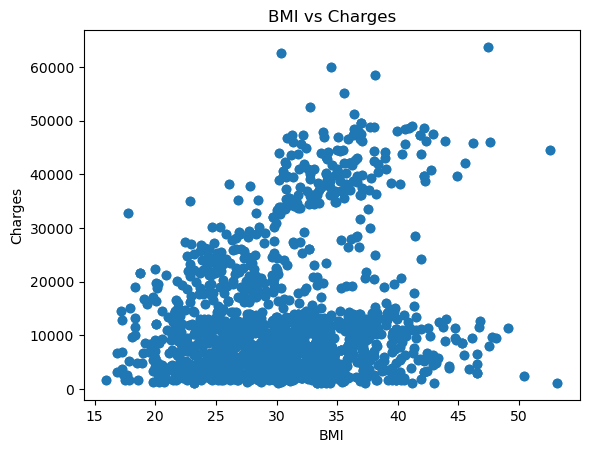

In [40]:
plt.figure()
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

### 2.4. Smoker vs Charges

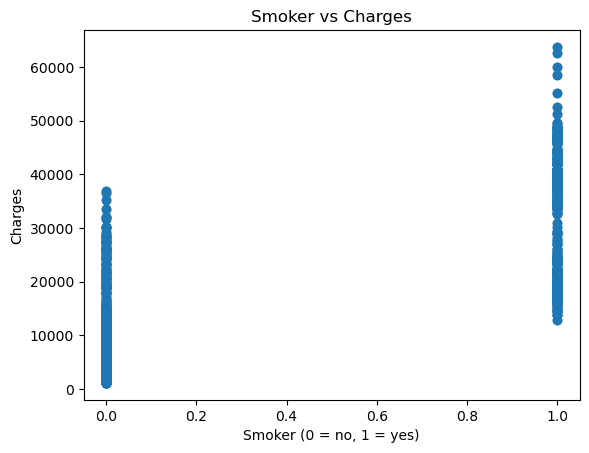

In [41]:
# chuyển smoker thành số để plot
df['smoker_num'] = df['smoker'].map({'yes':1, 'no':0})

plt.figure()
plt.scatter(df['smoker_num'], df['charges'])
plt.title("Smoker vs Charges")
plt.xlabel("Smoker (0 = no, 1 = yes)")
plt.ylabel("Charges")
plt.show()

### 2.5. Children vs Charges


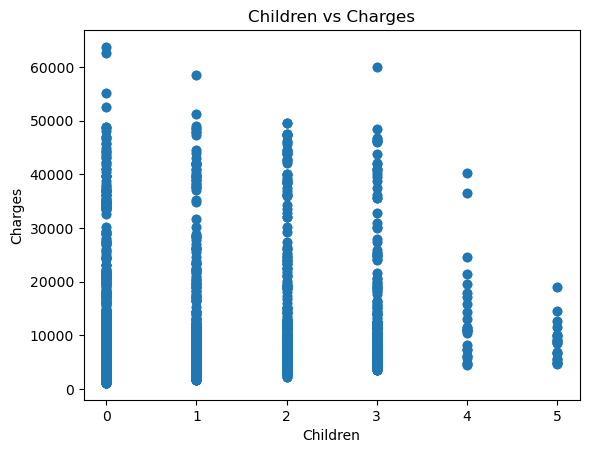

In [42]:
plt.figure()
plt.scatter(df['children'], df['charges'])
plt.title("Children vs Charges")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

## 3 Split Data Train Test Val

In [43]:
X = df.drop("charges", axis=1)
y = df["charges"]

### Encode categorical

In [44]:
X = pd.get_dummies(X, drop_first=True)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [46]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2217, 9)
Val: (277, 9)
Test: (278, 9)


### Scale dữ liệu train vì Lasso rất nhạy cảm 

In [47]:
class StandardScalerCustom:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        
    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [48]:
scaler = StandardScalerCustom()
    
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [49]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nMean của X_train sau scale:")
print(np.mean(X_train, axis=0))

print("\nStd của X_train sau scale:")
print(np.std(X_train, axis=0))

X_train shape: (2217, 9)
X_val shape: (277, 9)
X_test shape: (278, 9)
y_train shape: (2217,)
y_val shape: (277,)
y_test shape: (278,)

Mean của X_train sau scale:
age                 1.426213e-16
bmi                -4.855536e-16
children            1.025592e-16
smoker_num          6.409948e-18
sex_male           -1.217890e-16
smoker_yes         -3.204974e-17
region_northwest   -1.241927e-16
region_southeast    2.804352e-17
region_southwest    2.964601e-17
dtype: float64

Std của X_train sau scale:
age                 1.0
bmi                 1.0
children            1.0
smoker_num          1.0
sex_male            1.0
smoker_yes          1.0
region_northwest    1.0
region_southeast    1.0
region_southwest    1.0
dtype: float64
